# Notebook 2 : Data Cleaning, preprocessing and Exploration for corrupted dataset
### Nutrition Intelligence System | Predicting Protein, Fat, and Sugar in Foods

To explore our dataset and test our models strength , we used ai to corrupet our data,the dataset used is the one we preprocessed in notebook 1 before encoding , these are the modification that were made on the dataset


*  Missing values : ~8% NaN per numeric column ,27,870 total nulls
*   Duplicates: 105 duplicate rows

*  Outliers : Extreme values in Protein, Fat, Sugars

* Wrong dtype : Water, Fiber, Ash contain strings like 'N/A', 'trace', '??'

* Inconsistent labels'baked products', 'BAKED PRODUCTS', 'Dairy & Egg Products' etc.

* Negative values Impossible negatives in Calcium, Iron, Vitamin C, CholesterolRow orderFully shuffled

### 1.3 Corrupted Data
1. Data corruption(for testing)
2. Rediscovering dirty data
3. Cleaning data and filling missing values
4. Removing outliers from targets
5. Encoding Category
6. Removing food id Column  

### 1.3.1 Data corruption(for testing)

In this part we import the required libraries and load the corrupted csv file

In [ ]:
# Import required libraries
from google.colab import drive
import pandas as pd
import numpy as np
# Mount Google Drive to access dataset
drive.mount('/content/drive')
# File path for corrupted dataset stored in Google Drive
file_path_food_corrupted = '/content/drive/MyDrive/nutri_project/data/corrupted_food_dataset.csv'
# Load corrupted food dataset
corrupted_food_data = pd.read_csv(file_path_food_corrupted)

Mounted at /content/drive


### 1.3.2 Rediscovering dirty data

In this part we see the shape ,the nulls and all the problems in data

In [ ]:
print("Dataset shape:")
print(corrupted_food_data.shape)
print("\nDataset null values:")
print(corrupted_food_data.isna().sum())
print("\nDataset attributes type:")
print(corrupted_food_data.dtypes)


Dataset shape:
(6876, 51)

Dataset null values:
fdc_id                            0
description                       0
Protein                           0
Total lipid (fat)                 0
Carbohydrate, by difference       0
Ash                               0
Starch                            0
Alcohol, ethyl                    0
Water                             0
Caffeine                          0
Theobromine                       0
Fiber, total dietary              0
Calcium, Ca                       0
Iron, Fe                          0
Magnesium, Mg                     0
Phosphorus, P                     0
Potassium, K                      0
Sodium, Na                        0
Zinc, Zn                          0
Copper, Cu                        0
Fluoride, F                       0
Manganese, Mn                     0
Selenium, Se                      0
Vitamin A, RAE                    0
Carotene, beta                    0
Carotene, alpha                   0
Vitamin E (alpha

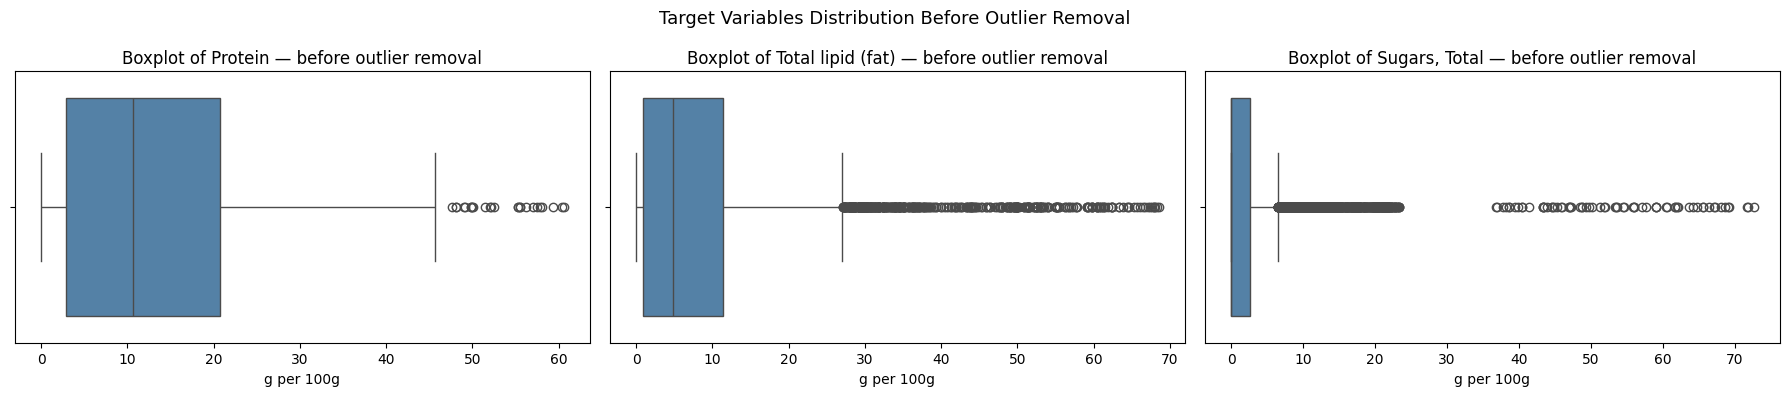

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#define the target variables
targets = ['Protein', 'Total lipid (fat)', 'Sugars, Total']
#create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
# sns.boxplot draws the box, whiskers and outlier dots automatically
#ax=axes[i] tells it which of the 3 subplots to draw in
for i, col in enumerate(targets):
    sns.boxplot(x=corrupted_food_data[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col} — before outlier removal')
    axes[i].set_xlabel('g per 100g')

plt.suptitle('Target Variables Distribution Before Outlier Removal', fontsize=13)
plt.tight_layout()
plt.show()

###Graph interpretation:
The blue box represents the middle 50% of foods between Q1 and Q3. The lines show the normal range, while the dots indicate outliers, representing foods with extreme values. Since all values are measured per 100g, any value above 100g is not possible and suggests incorrect data that should be fixed

In [ ]:
print("duplicate rows")
print(corrupted_food_data.duplicated().sum())

duplicate rows
18


In [ ]:
print("unique category labels")
print(corrupted_food_data['description'].nunique())

unique category labels
27


In [ ]:
print("negative values per column")
numeric_cols = corrupted_food_data.select_dtypes(include='number').columns
for col in numeric_cols:
    neg = (corrupted_food_data[col] < 0).sum()
    if neg > 0:
        print(f"{col}: {neg} negative values")

negative values per column


In [ ]:
print("string pollution in numeric columns")
bad_strings = ['N/A', 'trace', '??', 'na', 'NA', 'none']
for col in corrupted_food_data.columns:
    for bad in bad_strings:
        count = (corrupted_food_data[col].astype(str) == bad).sum()
        if count > 0:
            print(f"{col}: '{bad}' found {count} times")

string pollution in numeric columns



### 1.3.3  Cleaning data and filling missing values

In this step we're going to remove duplicates, fix the types and format as well as filling empty vallues

In [ ]:
# Convert to numeric any wrong types becomes nan
nutrient_cols = corrupted_food_data.columns[2:]
corrupted_food_data[nutrient_cols] = corrupted_food_data[nutrient_cols].apply(pd.to_numeric, errors='coerce')
print("After conversion:", corrupted_food_data.isnull().sum().sum())

After conversion: 0


In [ ]:
#removing duplicates and checking if they were correctly removed
food_data1 = corrupted_food_data.drop_duplicates().reset_index(drop=True)
print("After removing duplicates:")
print(food_data1.duplicated().sum())


After removing duplicates:
0


In [ ]:
# Fix inconsistent category labels
food_data1['description'] = food_data1['description'].str.strip().str.title()
print("Unique categories after fix:", food_data1['description'].nunique())

Unique categories after fix: 27


In [ ]:
# Fix negative values
food_data1[nutrient_cols] = food_data1[nutrient_cols].clip(lower=0)
print("Negatives fixed")

Negatives fixed


In [ ]:
print("negative values per column")
numeric_cols = food_data1.select_dtypes(include='number').columns
for col in numeric_cols:
    neg = (food_data1[col] < 0).sum()
    if neg > 0:
        print(f"{col}: {neg} negative values")

negative values per column


In [ ]:
from scipy.stats import skew

skewness = food_data1[nutrient_cols].skew().sort_values(ascending=False)
print(skewness)

Caffeine                          49.753253
Manganese, Mn                     44.196716
Selenium, Se                      41.907114
Tocopherol, beta                  41.158751
Theobromine                       39.320834
Cryptoxanthin, beta               35.006601
Vitamin C, total ascorbic acid    31.657502
Thiamin                           30.419498
Tocotrienol, delta                30.180156
Sodium, Na                        23.475554
Betaine                           22.089776
Vitamin A, RAE                    21.984563
Tocotrienol, alpha                19.227227
Potassium, K                      18.751589
Ash                               18.535372
Alcohol, ethyl                    18.386861
Riboflavin                        17.884260
Tocotrienol, gamma                17.331800
Carotene, alpha                   16.545975
Choline, total                    16.472284
Vitamin K (phylloquinone)         16.338534
Tocotrienol, beta                 15.873641
Copper, Cu                      

The result above shows that almost all values have skewness > 0 indicating right-skewed distribution cause by natrual high value food(linear regression struggle)

In [ ]:
for col in nutrient_cols:
    median_value = food_data1[col].median()
    food_data1[col].fillna(median_value, inplace=True)

print("Missing values after imputation:")
print(food_data1[nutrient_cols].isnull().sum().sum())

Missing values after imputation:
0


/tmp/ipykernel_30839/877530663.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  food_data1[col].fillna(median_value, inplace=True)


In [ ]:
food_data2= food_data1.copy()

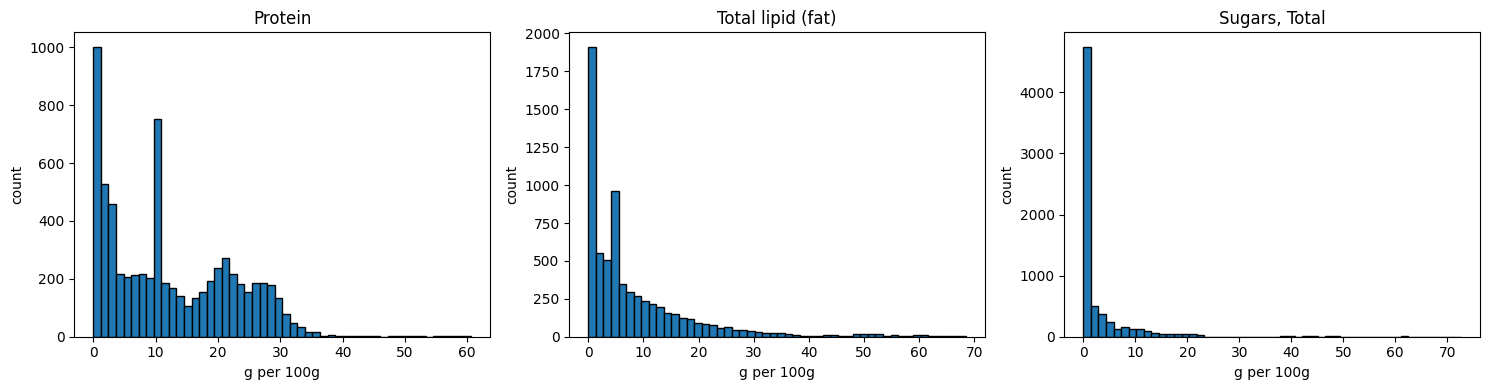

Protein: skewness = 0.64
Total lipid (fat): skewness = 2.40
Sugars, Total: skewness = 5.22


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
targets = ['Protein', 'Total lipid (fat)', 'Sugars, Total']

for i, col in enumerate(targets):
    axes[i].hist(food_data2[col], bins=50, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('g per 100g')
    axes[i].set_ylabel('count')

plt.tight_layout()
plt.show()

for col in targets:
    print(f"{col}: skewness = {food_data2[col].skew():.2f}")

This shows that my data is not normally distributed. Skewness > 1 indicates the data is highly right-skewed, meaning most values are exists at low ranges with some extreme high values.

Protein: 25 outliers
Total lipid (fat): 419 outliers
Sugars, Total: 939 outliers


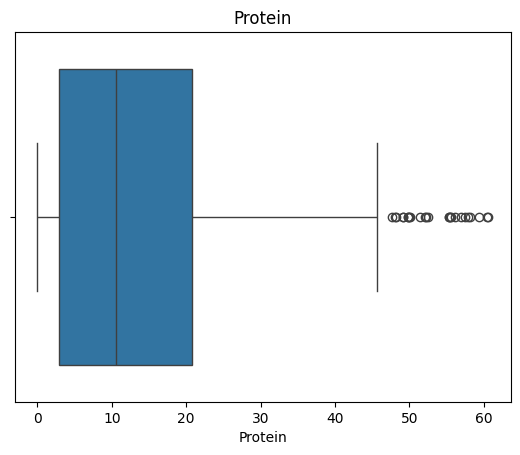

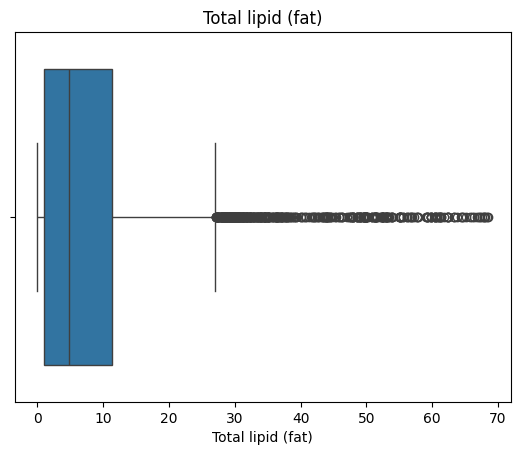

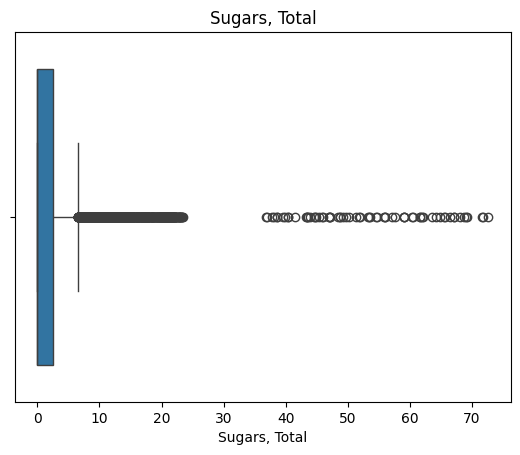

In [ ]:
#see how many outliers actually exists in data
for col in targets:
    Q1 = food_data2[col].quantile(0.25)
    Q3 = food_data2[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = food_data2[(food_data2[col] < lower) | (food_data2[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")
  #see it as boxplot
for col in targets:
    sns.boxplot(x=food_data2[col])
    plt.title(col)
    plt.show()

In [ ]:
targets = ['Protein', 'Total lipid (fat)', 'Sugars, Total']
domain_upper = 100

mask = pd.Series(True, index=food_data2.index)

for col in targets:
    mask &= food_data2[col] <= domain_upper

df_clean = food_data2[mask].reset_index(drop=True)

print("After domain cleaning:", df_clean.shape)

After domain cleaning: (6858, 51)


In [ ]:
#df_clean.to_csv('corrupted_food_dataset.csv', index=False)
#from google.colab import files  # only in Colab
#files.download('corrupted_food_dataset.csv')

### 1.3.5 Data encoding

For the corrupted dataset, we encode the category into numerical values by creating one column per category. One column is dropped to avoid redundancy, as we can deduced from the others.

In [ ]:
df_food_encoded = pd.get_dummies(df_clean, columns=['description'], prefix='cat', drop_first=True)

In [ ]:
#because the new columns were encoded as true false
#select the columns
dummy_cols = [col for col in df_food_encoded.columns if col.startswith('cat_')]
# Convert  them to 0 and 1
df_food_encoded[dummy_cols] = df_food_encoded[dummy_cols].astype(int)
print(df_food_encoded[dummy_cols].head())

   cat_Baby Foods  cat_Baked Products  cat_Beef Products  cat_Beverages  \
0               0                   0                  1              0   
1               0                   0                  0              0   
2               0                   0                  0              0   
3               0                   0                  0              0   
4               0                   0                  0              0   

   cat_Breakfast Cereals  cat_Cereal Grains And Pasta  \
0                      0                            0   
1                      0                            0   
2                      0                            0   
3                      0                            0   
4                      0                            0   

   cat_Dairy & Egg Products  cat_Dairy And Egg Products  cat_Fast Foods  \
0                         0                           0               0   
1                         0                           0 

### 1.3.6  Removing food id
After encoding the category the last step is to remove the food id since it has no effect on our prediction.

In [ ]:
final_corrupted_food_data = df_food_encoded.drop(columns=['fdc_id'])

In [ ]:
print(final_corrupted_food_data.shape)

(6858, 75)


In [ ]:
final_corrupted_food_data.to_csv('final_corrupted_food_dataset.csv', index=False)
from google.colab import files  # only in Colab
#files.download('final_corrupted_food_dataset.csv')